In [5]:
import  DeepMIMOv3
import numpy as np

# Load the default parameters
parameters = DeepMIMOv3.default_params()

# Set the main folder containing extracted scenarios
parameters['dataset_folder'] = '/mnt/rmc/PHD_rmc/DeepMimo/scenarios'

# Ray-tracing scenario
parameters['scenario'] = 'I3_2p4'  # The adopted ray tracing scenario

# Dynamic Scenario Scenes
parameters['dynamic_scenario_scenes'] = [1]  # 仅用于动态场景，[1]表示只使用第一个时间帧/场景快照

# Active base stations
parameters['active_BS'] = np.array([1,2])  # 同时激活基站1和基站2

# Active users
# parameters['user_row_first'] = 1    # The first row of the considered user section
# parameters['user_row_last'] = 1159  # The last row of the considered user section
parameters['user_rows'] = np.arange(0,1159)  #明确指定用户行的索引范围

# Subsampling of active users
parameters['row_subsampling'] = 1  # 不跳过任何用户行，每1行取1行
parameters['user_subsampling'] = 1 # 不跳过行内任何用户，每1个用户取1个

# Antenna array dimensions
#基站天线配置
parameters['bs_antenna'] = {
    'shape': np.array([8, 4]),  # 8*4天线阵列
    'spacing': 0.5,  # 半波长间距
    'rotation': np.array([0, -45, 0]),  # [天线极化倾角，向下倾斜45°，方位角]
    'FoV': np.array([180, 180]),  # 180°*180°视场(水平和竖直方向)
    'radiation_pattern': 'isotropic'  # 全向辐射（无方向性） 0 in MATLAB means isotropic
}

#用户天线配置
parameters['ue_antenna'] = {
    'shape': np.array([1, 1]),  # 1*1单天线(SISO配置)
    'spacing': 0.5,  # 半波长间距
    'rotation': np.array([0, 0, 0]),  # UE antenna orientation
    'FoV': np.array([360, 180]),  # 360*180 全向覆盖
    'radiation_pattern': 'isotropic'  # 全向辐射 0 in MATLAB means isotropic
}

# System parameters
parameters['bandwidth'] = 0.05  # The bandwidth in GHz  系统带宽50MHz
parameters['activate_RX_filter'] = 1  # 接收端为理想低通滤波器，时域为sinc函数频域为矩形窗


# Channel parameters
parameters['num_paths'] = 25  # 链路考虑最多25条多径

# OFDM parameters
parameters['OFDM'] = {
    'subcarriers': 512,  # 共512个子载波
    'selected_subcarriers': np.arange(8, 513, 8),  # Sampled subcarriers (8, 16, ..., 512)
    'bandwidth': 0.05,  # 50 MHz
    'RX_filter': 1  # Activate RX filtering
}

# Additional settings
parameters['enable_doppler'] = 0  # 禁用多普勒频移，假设用户和基站是静止的或移动速度可忽略
parameters['enable_dual_polar'] = 0  # 禁用双极化，只考虑单极化传输
# 打印参数（可选）
for key, value in parameters.items():
    print(f"{key}: {value}")


# Generate data
dataset = DeepMIMOv3.generate_data(parameters)

dataset_folder: /mnt/rmc/PHD_rmc/DeepMimo/scenarios
scenario: I3_2p4
dynamic_scenario_scenes: [1]
num_paths: 25
active_BS: [1 2]
user_rows: [   0    1    2 ... 1156 1157 1158]
user_subsampling: 1
bs_antenna: {'shape': array([8, 4]), 'spacing': 0.5, 'rotation': array([  0, -45,   0]), 'FoV': array([180, 180]), 'radiation_pattern': 'isotropic'}
ue_antenna: {'shape': array([1, 1]), 'spacing': 0.5, 'rotation': array([0, 0, 0]), 'FoV': array([360, 180]), 'radiation_pattern': 'isotropic'}
enable_doppler: 0
enable_dual_polar: 0
enable_BS2BS: 1
OFDM_channels: 1
OFDM: {'subcarriers': 512, 'selected_subcarriers': array([  8,  16,  24,  32,  40,  48,  56,  64,  72,  80,  88,  96, 104,
       112, 120, 128, 136, 144, 152, 160, 168, 176, 184, 192, 200, 208,
       216, 224, 232, 240, 248, 256, 264, 272, 280, 288, 296, 304, 312,
       320, 328, 336, 344, 352, 360, 368, 376, 384, 392, 400, 408, 416,
       424, 432, 440, 448, 456, 464, 472, 480, 488, 496, 504, 512]), 'bandwidth': 0.05, 'RX_filter': 

Generating channels: 100%|██████████| 118959/118959 [01:43<00:00, 1146.44it/s]



BS-BS Channels


Generating channels: 100%|██████████| 2/2 [00:00<00:00, 40.14it/s]



Basestation 2

UE-BS Channels


Generating channels: 100%|██████████| 118959/118959 [01:20<00:00, 1485.08it/s]



BS-BS Channels


Generating channels: 100%|██████████| 2/2 [00:00<00:00, 70.80it/s]


In [6]:
# 打印数据集的字段名
print(dataset[0].keys())

print(len(dataset[0]['user']['location']))

dict_keys(['user', 'basestation', 'location'])
118959


In [9]:
# Number of basestations
len(dataset)

2

In [10]:
import numpy as np

# 选择第1个基站的数据 (索引0)
bs_idx = 0
data = dataset[bs_idx]

print(f"================ 正在检查 BS {bs_idx+1} 的数据结构 ================\n")

# -----------------------------------------------------------
# 1. 检查 'user' 字典 (最核心的数据)
# -----------------------------------------------------------
print(f"--- [User Data] Keys inside dataset[{bs_idx}]['user'] ---")
user_dict = data['user']

for key, value in user_dict.items():
    # 获取数据类型
    d_type = type(value)
    
    # 如果是 Numpy 数组，打印形状 (Shape)
    if isinstance(value, np.ndarray):
        info = f"Shape: {value.shape}"
    # 如果是列表，打印长度 (Length)
    elif isinstance(value, list):
        info = f"List Length: {len(value)}"
    # 其他类型直接打印值
    else:
        info = f"Value: {value}"
        
    print(f"Key: {key:<12} | Type: {d_type.__name__:<10} | {info}")

print("\n" + "-"*60 + "\n")

# -----------------------------------------------------------
# 2. 检查 'basestation' 字典 (配置数据)
# -----------------------------------------------------------
print(f"--- [Basestation Data] Keys inside dataset[{bs_idx}]['basestation'] ---")
bs_dict = data['basestation']

for key, value in bs_dict.items():
    if isinstance(value, np.ndarray):
        info = f"Shape: {value.shape} \n    -> Value: {value}" # 打印具体坐标值
    else:
        info = f"Value: {value}"
    print(f"Key: {key:<12} | Type: {type(value).__name__:<10} | {info}")

print("\n" + "-"*60 + "\n")

# -----------------------------------------------------------
# 3. 深入检查 'paths' (射线几何参数)
# 因为 paths 是一个结构体列表，上面的循环看不到内部细节
# -----------------------------------------------------------
print(f"--- [Paths Detail] Inspecting 1st User's Paths ---")
# 取出第0个用户的路径信息
first_user_paths = user_dict['paths'][0] 

if first_user_paths is None:
    print("User 0 has no valid paths.")
else:
    print(f"User 0 has {first_user_paths['num_paths']} paths.")
    print("Internal keys of a path object:")
    # 遍历 path 内部的键 (如 DoA, DoD, ToA, Phase)
    for p_key, p_val in first_user_paths.items():
        if isinstance(p_val, np.ndarray):
             print(f"  - {p_key:<12}: Shape {p_val.shape}")
        else:
             print(f"  - {p_key:<12}: {p_val}")

================ 正在检查 BS 1 的数据结构 ================

--- [User Data] Keys inside dataset[0]['user'] ---
Key: paths        | Type: ndarray    | Shape: (118959,)
Key: LoS          | Type: ndarray    | Shape: (118959,)
Key: location     | Type: ndarray    | Shape: (118959, 3)
Key: distance     | Type: ndarray    | Shape: (118959,)
Key: pathloss     | Type: ndarray    | Shape: (118959,)
Key: channel      | Type: ndarray    | Shape: (118959, 1, 32, 64)

------------------------------------------------------------

--- [Basestation Data] Keys inside dataset[0]['basestation'] ---
Key: paths        | Type: ndarray    | Shape: (2,) 
    -> Value: [{'num_paths': 3, 'DoD_phi': array([-9.00000e+01,  1.35237e-10, -2.95112e+01], dtype=float32), 'DoD_theta': array([90.    , 90.    , 90.0011], dtype=float32), 'DoA_phi': array([-9.00000e+01,  1.35237e-10, -2.95023e+01], dtype=float32), 'DoA_theta': array([90.    , 90.    , 90.0011], dtype=float32), 'phase': array([175.863 ,  43.1858, 100.009 ], dtype=flo

In [8]:
# Keys of a channel
dataset[0]['user'].keys()
dataset[0]['user']['LoS']

array([1, 1, 1, ..., 0, 0, 0], dtype=int8)

In [13]:
# Number of UEs
len(dataset[0]['user']['channel'])

118959

In [14]:
# Shape of the channel matrix
dataset[0]['user']['channel'].shape

(118959, 1, 32, 64)

In [29]:
# Shape of BS 0 - UE 0 channel
dataset[0]['user']['channel'][0].shape

(1, 32, 64)

In [31]:
# Path properties of BS 0 - UE 0
print(dataset[0]['user']['paths'][0])
print(dataset[1]['user']['paths'][0])

{'num_paths': 5, 'DoD_phi': array([-39.0407,  71.1902, -61.6811, -12.3236, -61.6811], dtype=float32), 'DoD_theta': array([104.602 ,  96.1723,  99.0406,  95.0447, 106.462 ], dtype=float32), 'DoA_phi': array([ 140.959 ,  108.81  , -118.319 ,   12.3236, -118.319 ],
      dtype=float32), 'DoA_theta': array([ 75.3983,  83.8277,  80.9594,  84.9553, 106.462 ], dtype=float32), 'phase': array([-170.    ,  139.165 ,  129.616 ,   50.9041,  -82.4183],
      dtype=float32), 'ToA': array([1.85301e-08, 4.34475e-08, 2.97287e-08, 5.31249e-08, 3.06143e-08],
      dtype=float32), 'LoS': array([1., 0., 0., 0., 0.], dtype=float32), 'power': array([3.2018440e-06, 1.7630319e-07, 1.6135405e-07, 1.3947303e-07,
       1.7015342e-09], dtype=float32)}
{'num_paths': 5, 'DoD_phi': array([-30.5893, -13.7692,  73.9108, -53.2628, -30.5893], dtype=float32), 'DoD_theta': array([101.689 ,  95.3544,  93.8106,  98.1807, 111.018 ], dtype=float32), 'DoA_phi': array([ 30.5893, 167.706 ,  73.9108, -53.2628,  30.5893], dtype=fl

(1, 32, 64)


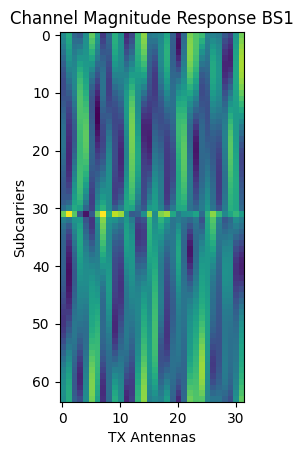

(1, 32, 64)


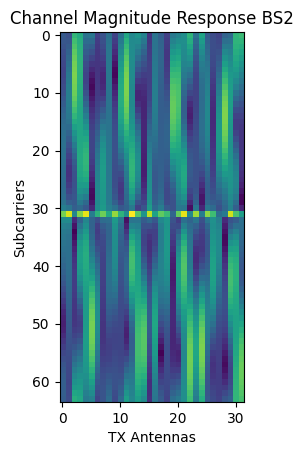

In [12]:
## Visualization of a channel matrix

from matplotlib import pyplot as plt


# Visualize channel magnitude response
# First, select indices of a user and bs
ue_idx = 1000
for bs_idx in range(len(parameters['active_BS'])):
    # Import channel
    plt.figure()
    channel = dataset[bs_idx]['user']['channel'][ue_idx]
    print(channel.shape)
    # Take only the first antenna pair
    plt.imshow(np.abs(channel.T))
    plt.title('Channel Magnitude Response'+' BS{}'.format(bs_idx+1))
    plt.xlabel('TX Antennas')
    plt.ylabel('Subcarriers')
    plt.show()

# 保存数据到数据集

In [13]:
# 保存到文件 USER pos & CSI & LoS status
pos_houzhui = ['_BS1.txt','_BS2.txt']
csi_houzhui = ['_BS1.npy','_BS2.npy']
LoS_houzhui = ['_BS1.txt','_BS2.txt']

for bs_idx in range(len(parameters['active_BS'])):
    pos_save_name = parameters['dataset_folder'] + '/' + parameters['scenario'] + '/UE_pos'
    np.savetxt(pos_save_name + pos_houzhui[bs_idx], dataset[bs_idx]['user']['location'], fmt="%.6f", delimiter=" ")
    
    # 保存LoS状态数据
    LoS_status_save_name = parameters['dataset_folder'] + '/' + parameters['scenario'] + '/UE_LoS'
    np.savetxt(LoS_status_save_name + LoS_houzhui[bs_idx], 
              dataset[bs_idx]['user']['LoS'], 
              fmt="%d", 
              delimiter=" ")
    
    csi_save_name = parameters['dataset_folder'] + '/' + parameters['scenario'] + '/UE_CSI'
    dataset[bs_idx]['user']['channel'].shape
    np.save(csi_save_name + csi_houzhui[bs_idx],dataset[bs_idx]['user']['channel'])

In [14]:
print(bs_idx)
print(f"BS{bs_idx+1} location:", dataset[bs_idx]['location'])

1
BS2 location: [31.83499908  9.62388039  2.        ]


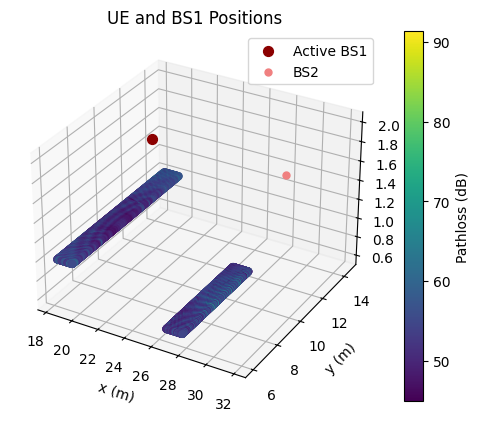

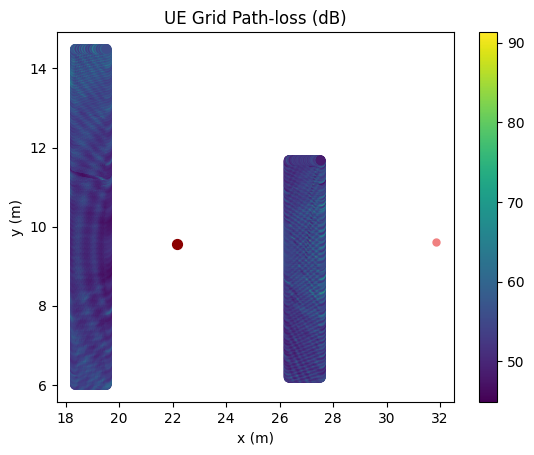

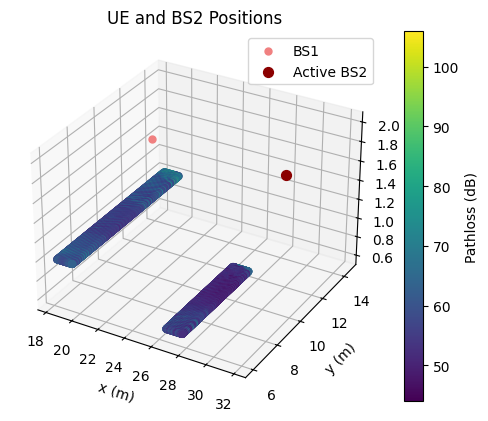

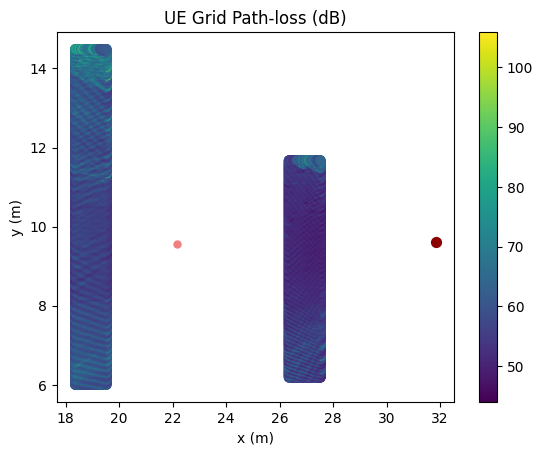

In [15]:
## Visualization of the UE positions and path-losses

for bs_idx in range(len(parameters['active_BS'])):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    # 绘制当前BS覆盖的UE位置和路径损耗
    loc_x = dataset[bs_idx]['user']['location'][:, 0]
    loc_y = dataset[bs_idx]['user']['location'][:, 1]
    loc_z = dataset[bs_idx]['user']['location'][:, 2]
    pathloss = dataset[bs_idx]['user']['pathloss']
    im = ax.scatter(loc_x, loc_y, loc_z, c=pathloss)
    
    # 绘制当前BS的位置（红色）
    # 1. 绘制所有基站位置
    all_bs_locations = dataset[bs_idx]['basestation']['location']  # 所有基站位置
    for i, bs_loc in enumerate(all_bs_locations):
        if i == bs_idx:  # 当前激活基站
            ax.scatter(bs_loc[0], bs_loc[1], bs_loc[2], 
                      c='darkred', s=200, marker='.', label=f'Active BS{bs_idx+1}')
        else:  # 其他基站
            ax.scatter(bs_loc[0], bs_loc[1], bs_loc[2], 
                      c='lightcoral', s=100, marker='.', label=f'BS{i+1}')

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    plt.title(f'UE and BS{bs_idx+1} Positions')
    plt.legend()
    plt.colorbar(im, label='Pathloss (dB)')
    plt.show()  # 显示当前图，避免叠加
    
    # 绘制二维图
    fig = plt.figure()
    ax = fig.add_subplot()
    im = ax.scatter(loc_x, loc_y, c=pathloss)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    fig.colorbar(im, ax=ax)
    ttl = plt.title('UE Grid Path-loss (dB)')
    # 绘制所有基站位置
    all_bs_locations = dataset[bs_idx]['basestation']['location']  # 所有基站位置
    for i, bs_loc in enumerate(all_bs_locations):
        if i == bs_idx:  # 当前激活基站
            ax.scatter(bs_loc[0], bs_loc[1], 
                      c='darkred',s=200, marker='.', label=f'Active BS{bs_idx+1}')
        else:  # 其他基站
            ax.scatter(bs_loc[0], bs_loc[1], 
                      c='lightcoral',s=100, marker='.', label=f'BS{i+1}')
    plt.show()

BS location: [31.83499908  9.62388039  2.        ]
User locations shape: (118959, 3)
LoS status samples: [0 0 0 0 0]


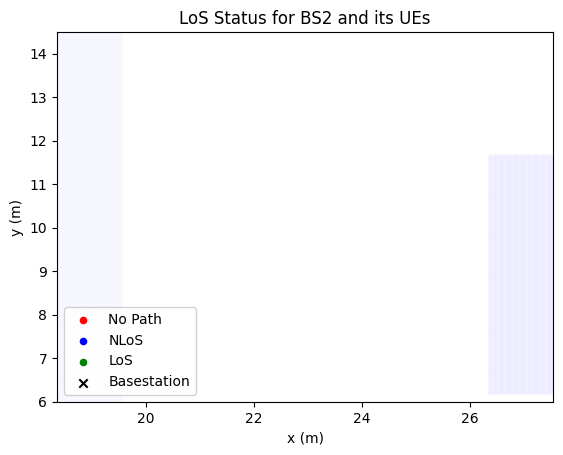

In [16]:
from DeepMIMOv3.visualization import plot_LoS_status, plot_coverage
# Plotting LoS status for all users
bs_idx = 1  # 选择基站索引

# 提取数据（确保形状正确）
bs_location = dataset[bs_idx]['location'] # 当前基站位置 (3,)
user_location = dataset[bs_idx]['user']['location']  # 用户位置 (n_UE, 3)
LoS_status = dataset[bs_idx]['user']['LoS']  # 转换为 0/1

# 验证数据
print("BS location:", bs_location)
print("User locations shape:", user_location.shape)
print("LoS status samples:", LoS_status[:5])  # 查看前5个值

# 绘制LoS状态
plot_LoS_status(bs_location, user_location, LoS_status)
plt.title(f'LoS Status for BS{bs_idx + 1} and its UEs')
plt.show()

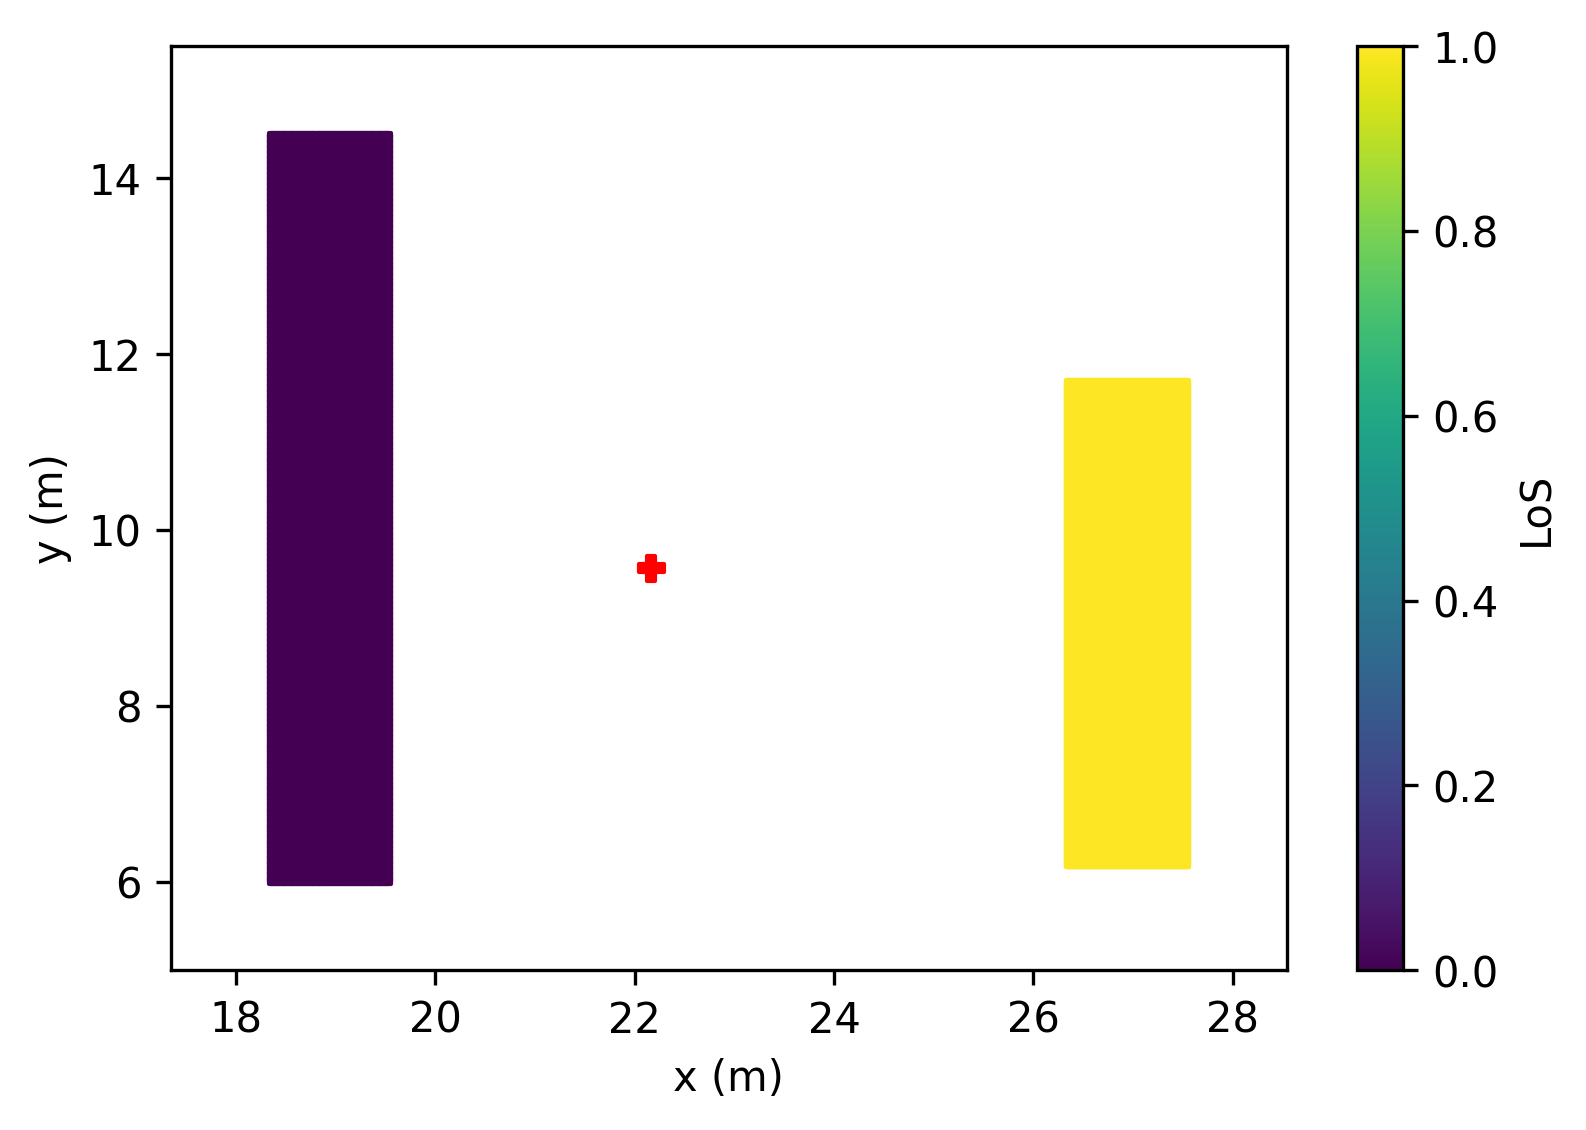

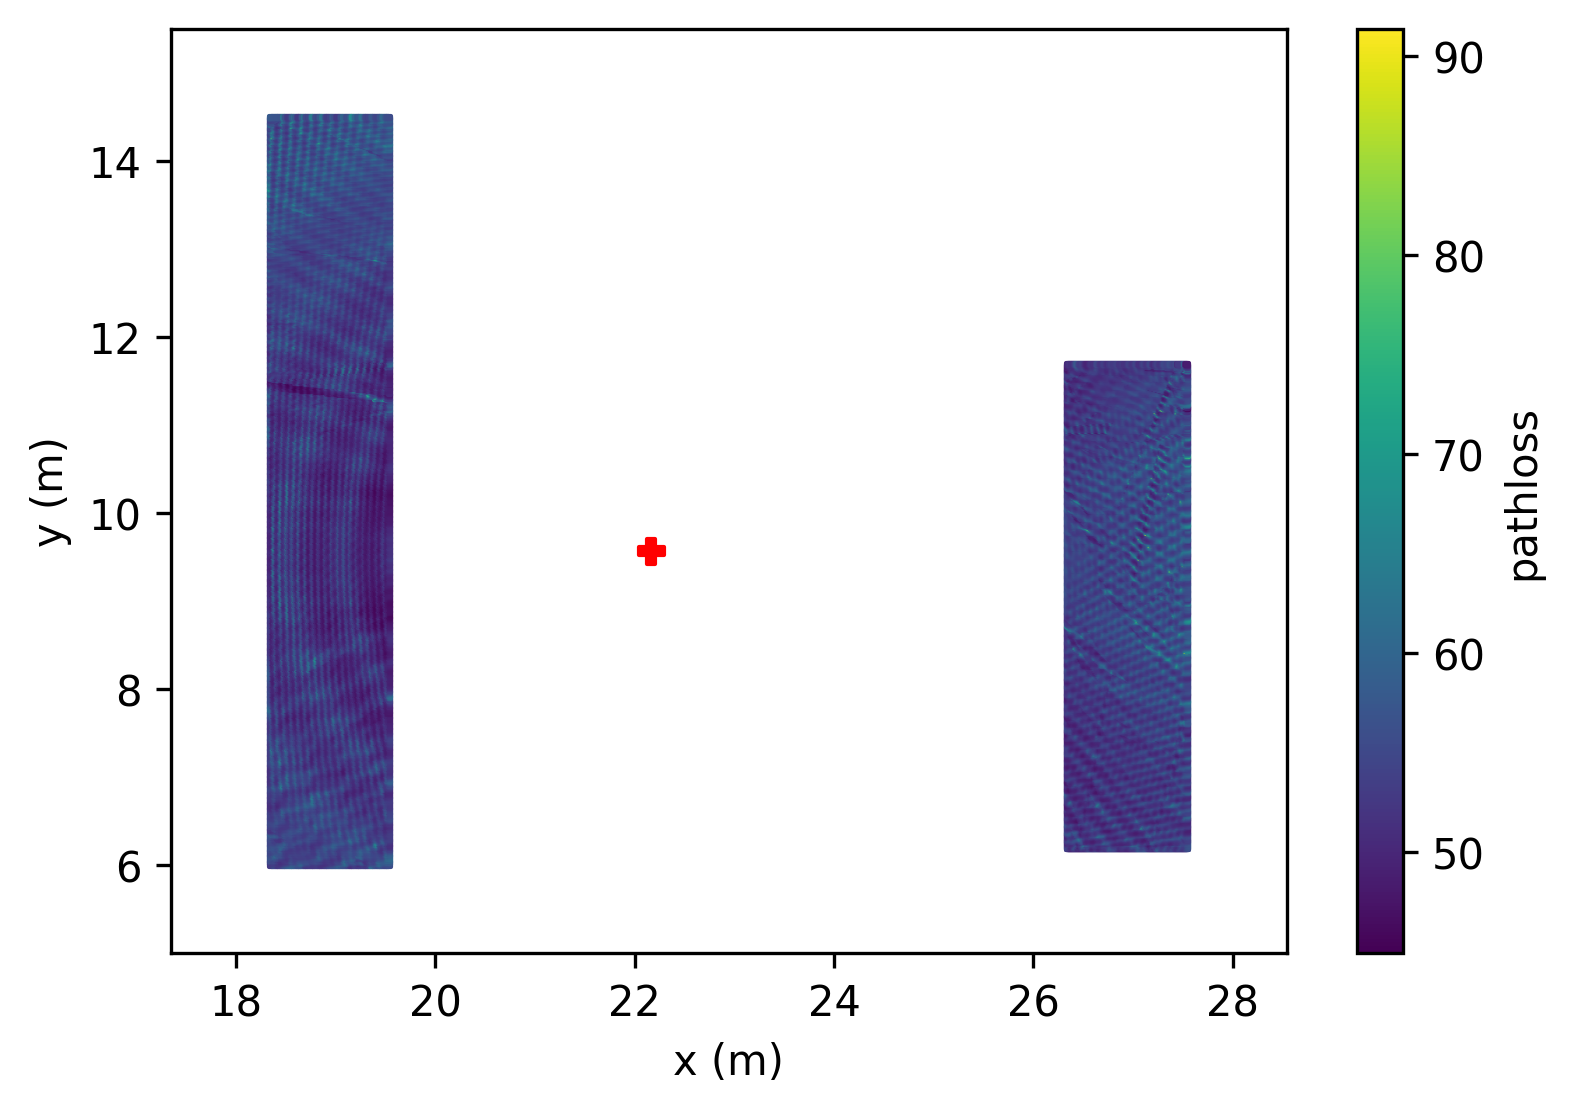

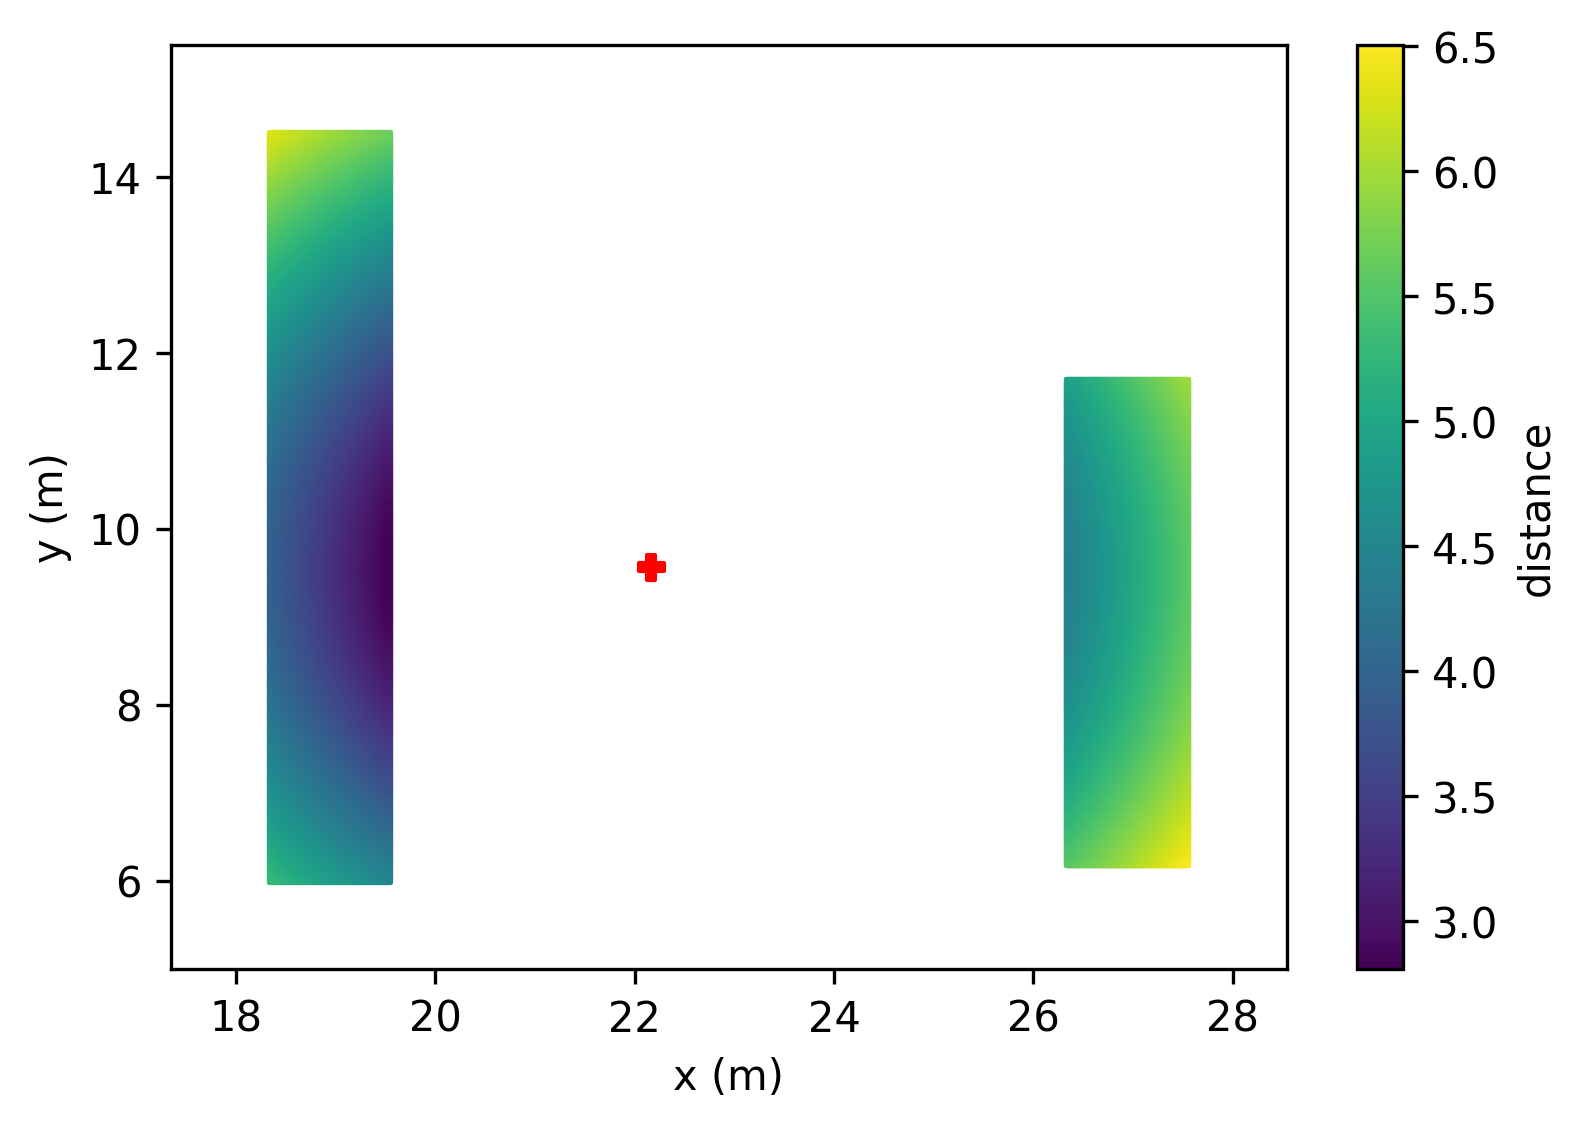

In [17]:
# Automatic 2D/3D plot
var_names = ['LoS', 'pathloss', 'distance']
for var_name in var_names:
    plot_coverage(dataset[0]['user']['location'], dataset[0]['user'][var_name],
                  bs_pos=dataset[0]['location'], cbar_title=var_name, proj_3D=False)

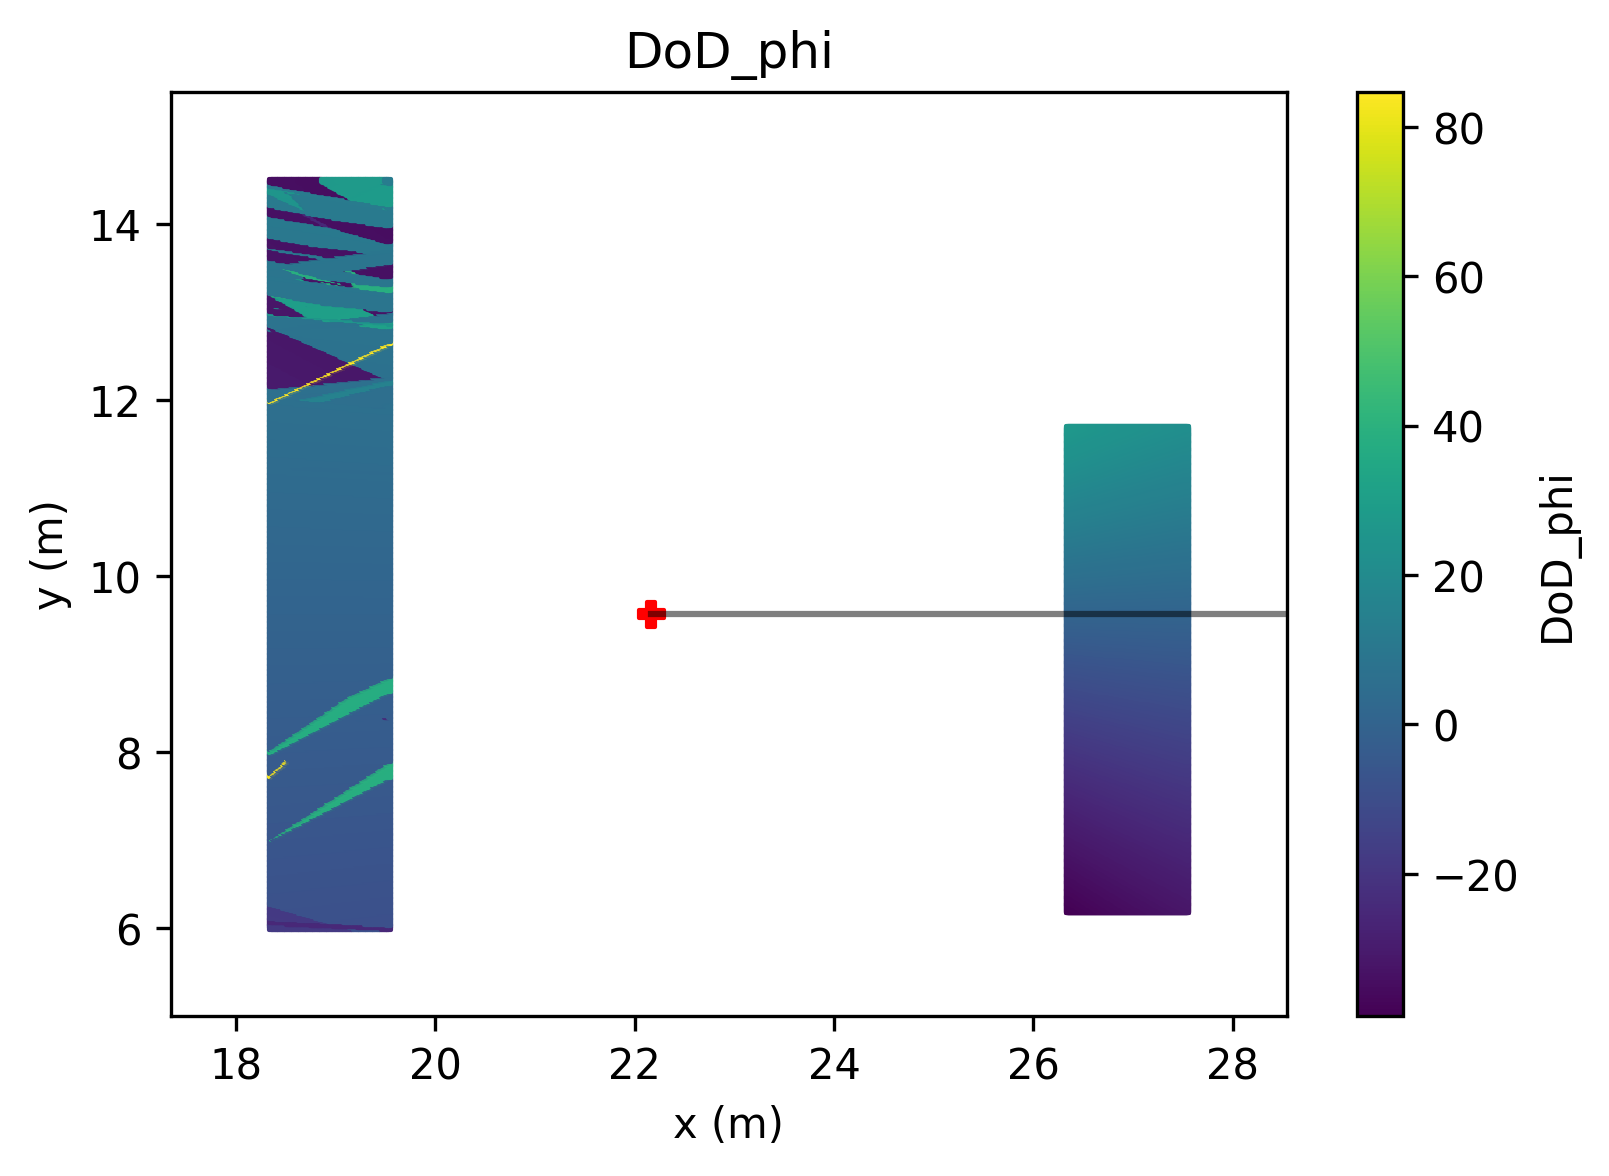

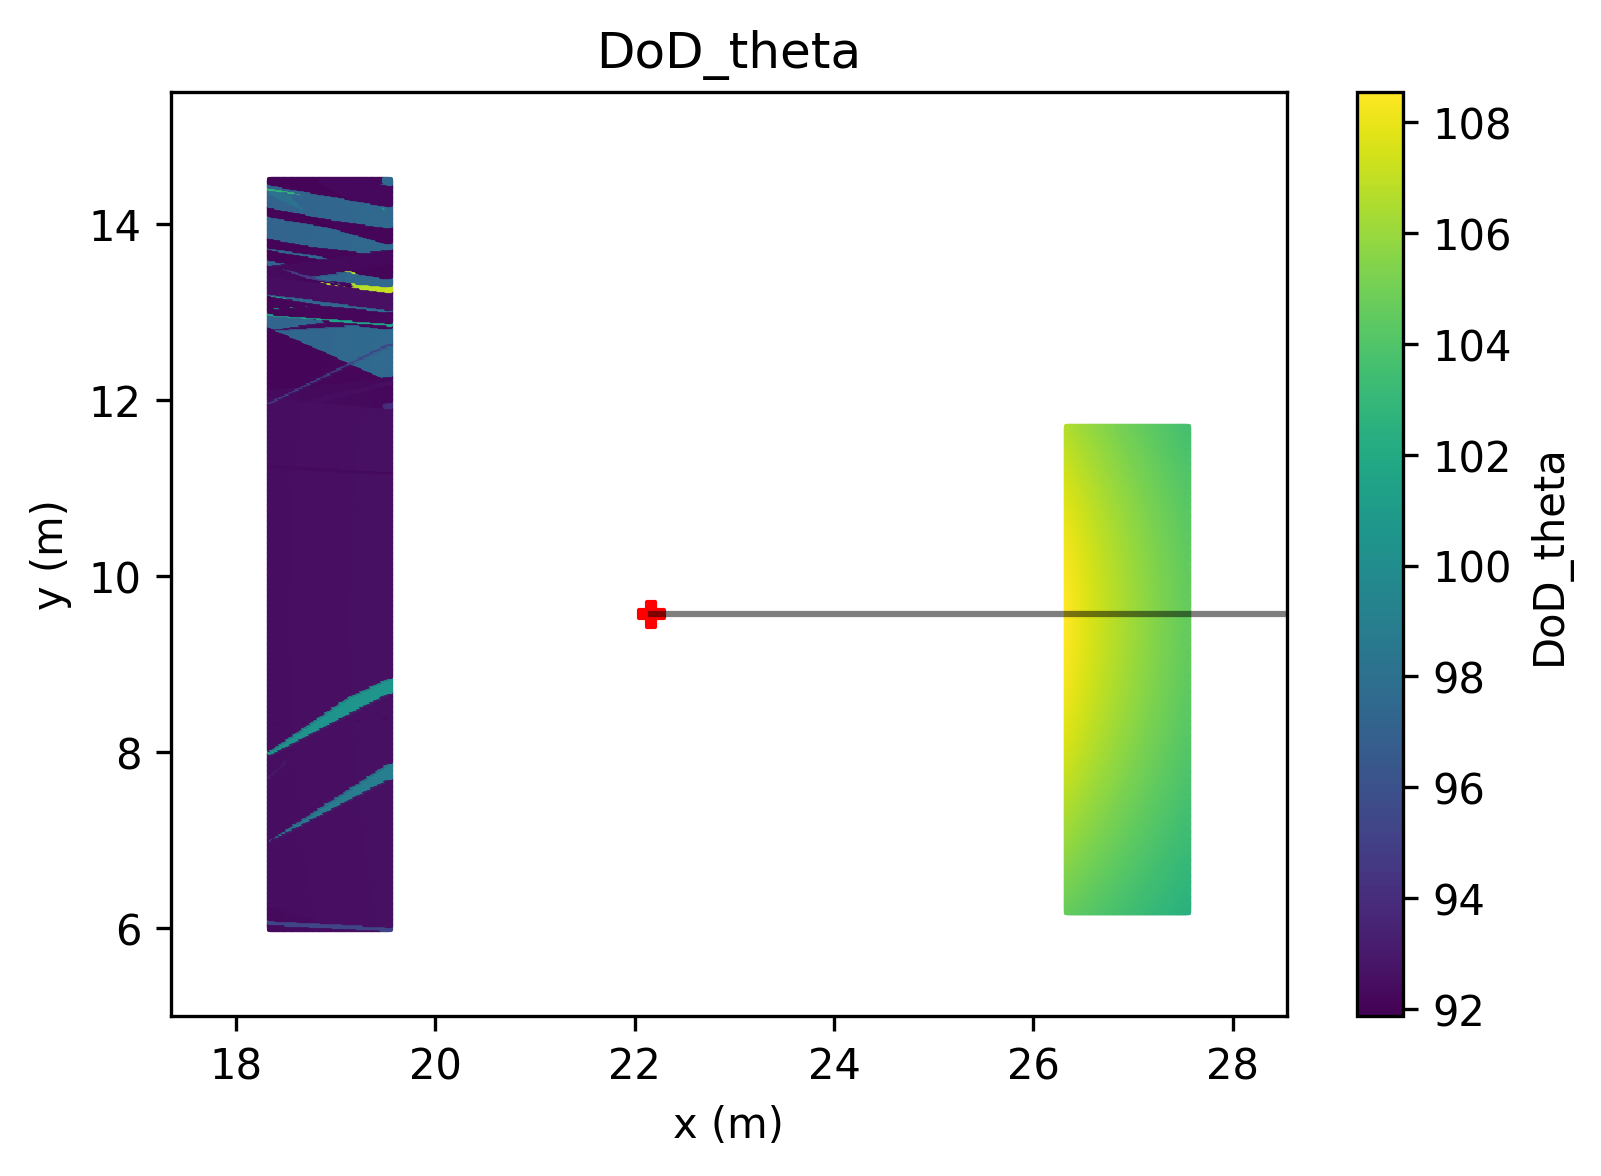

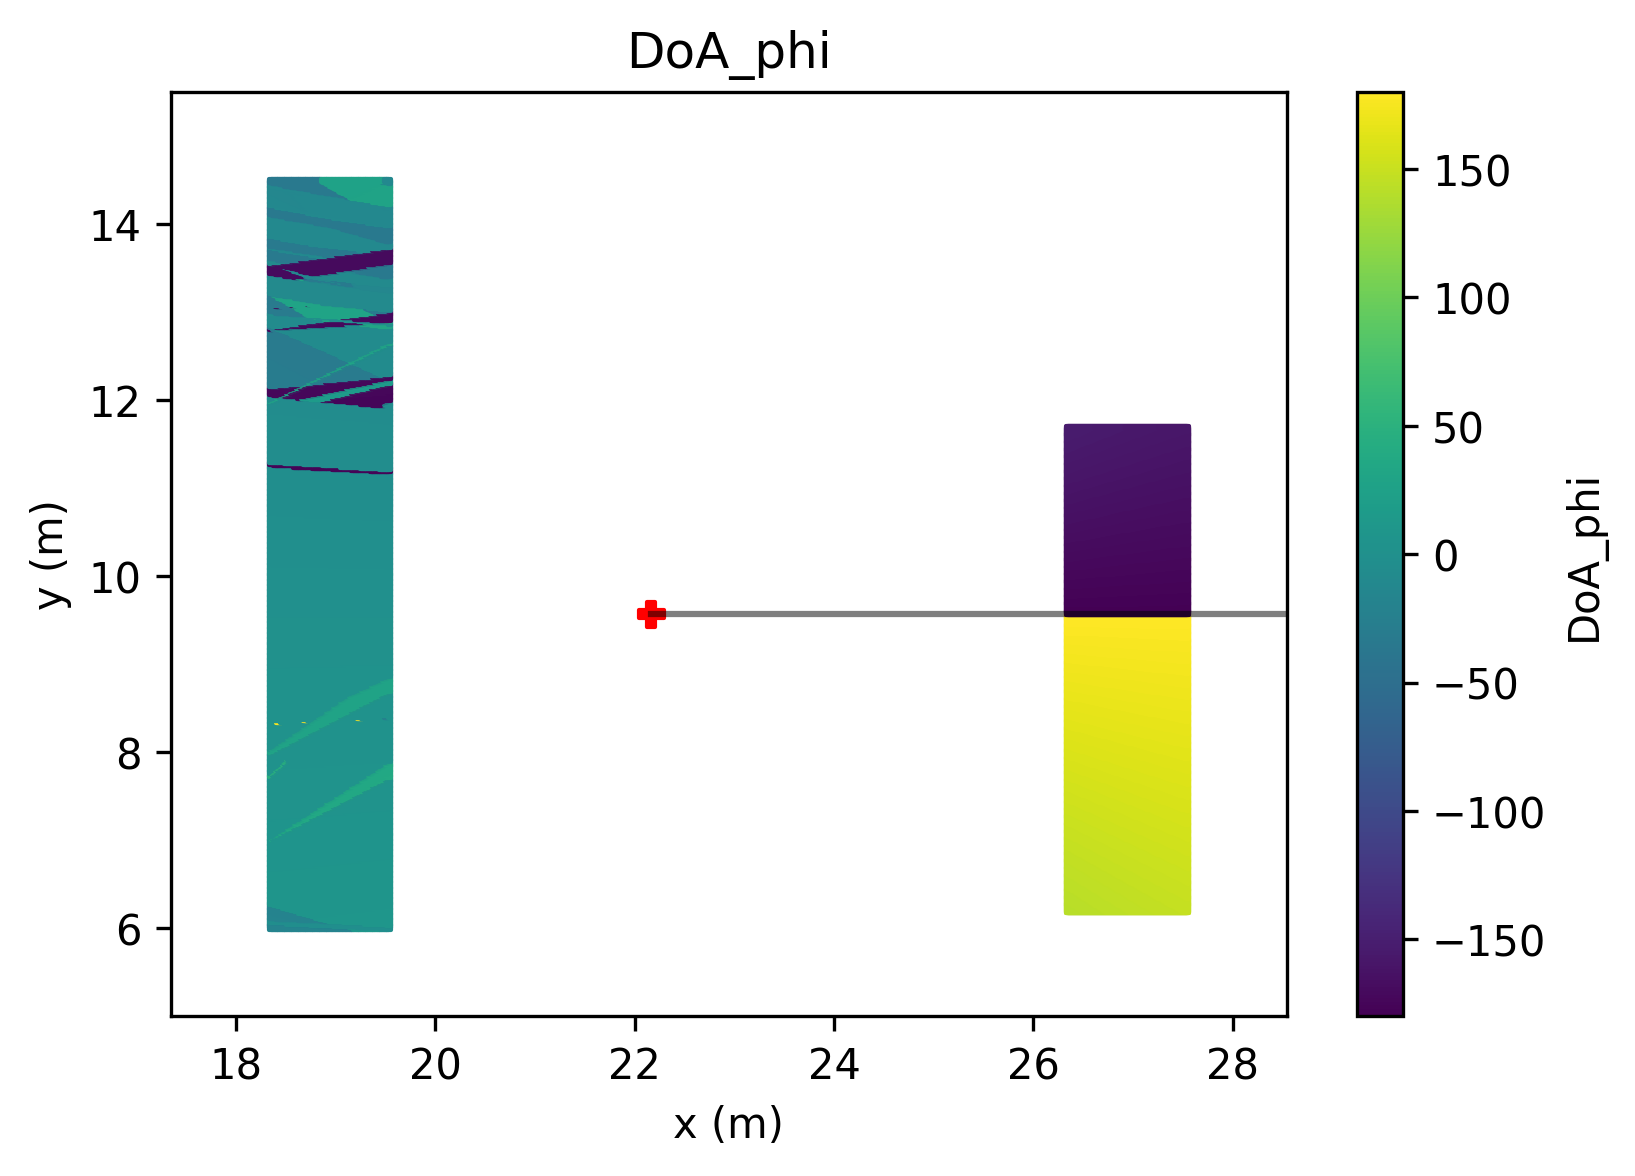

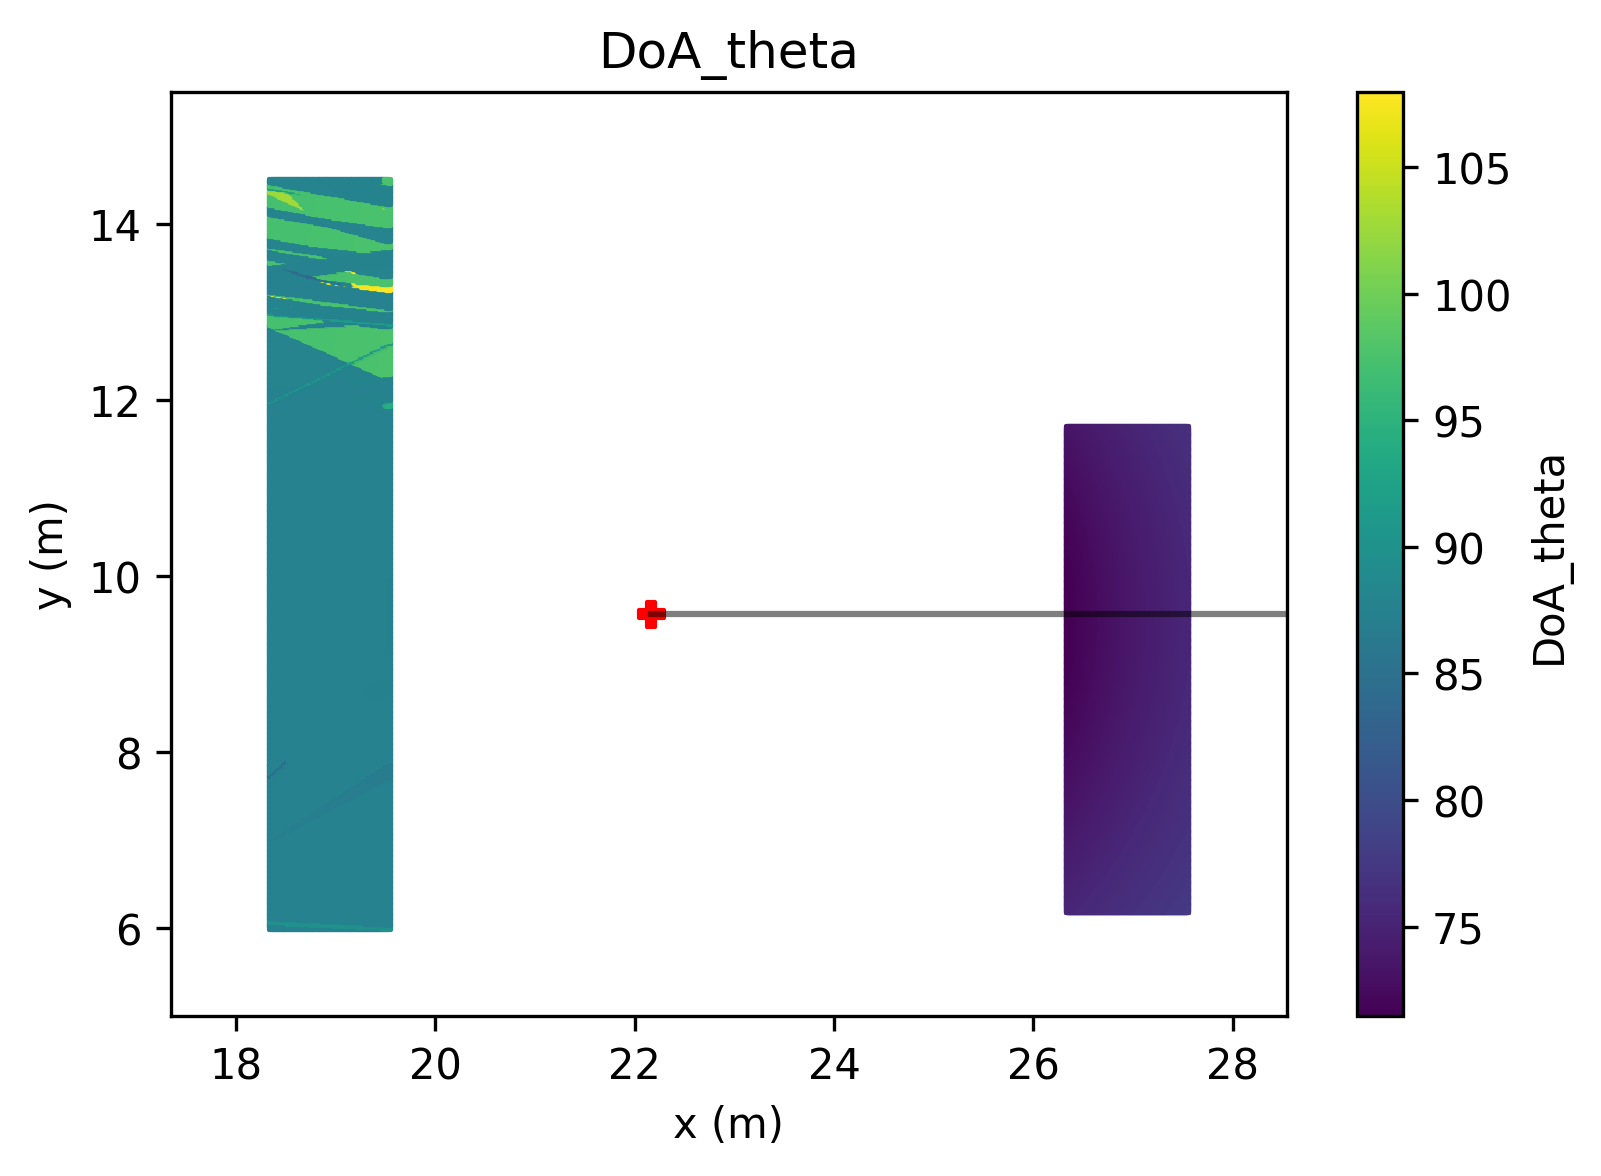

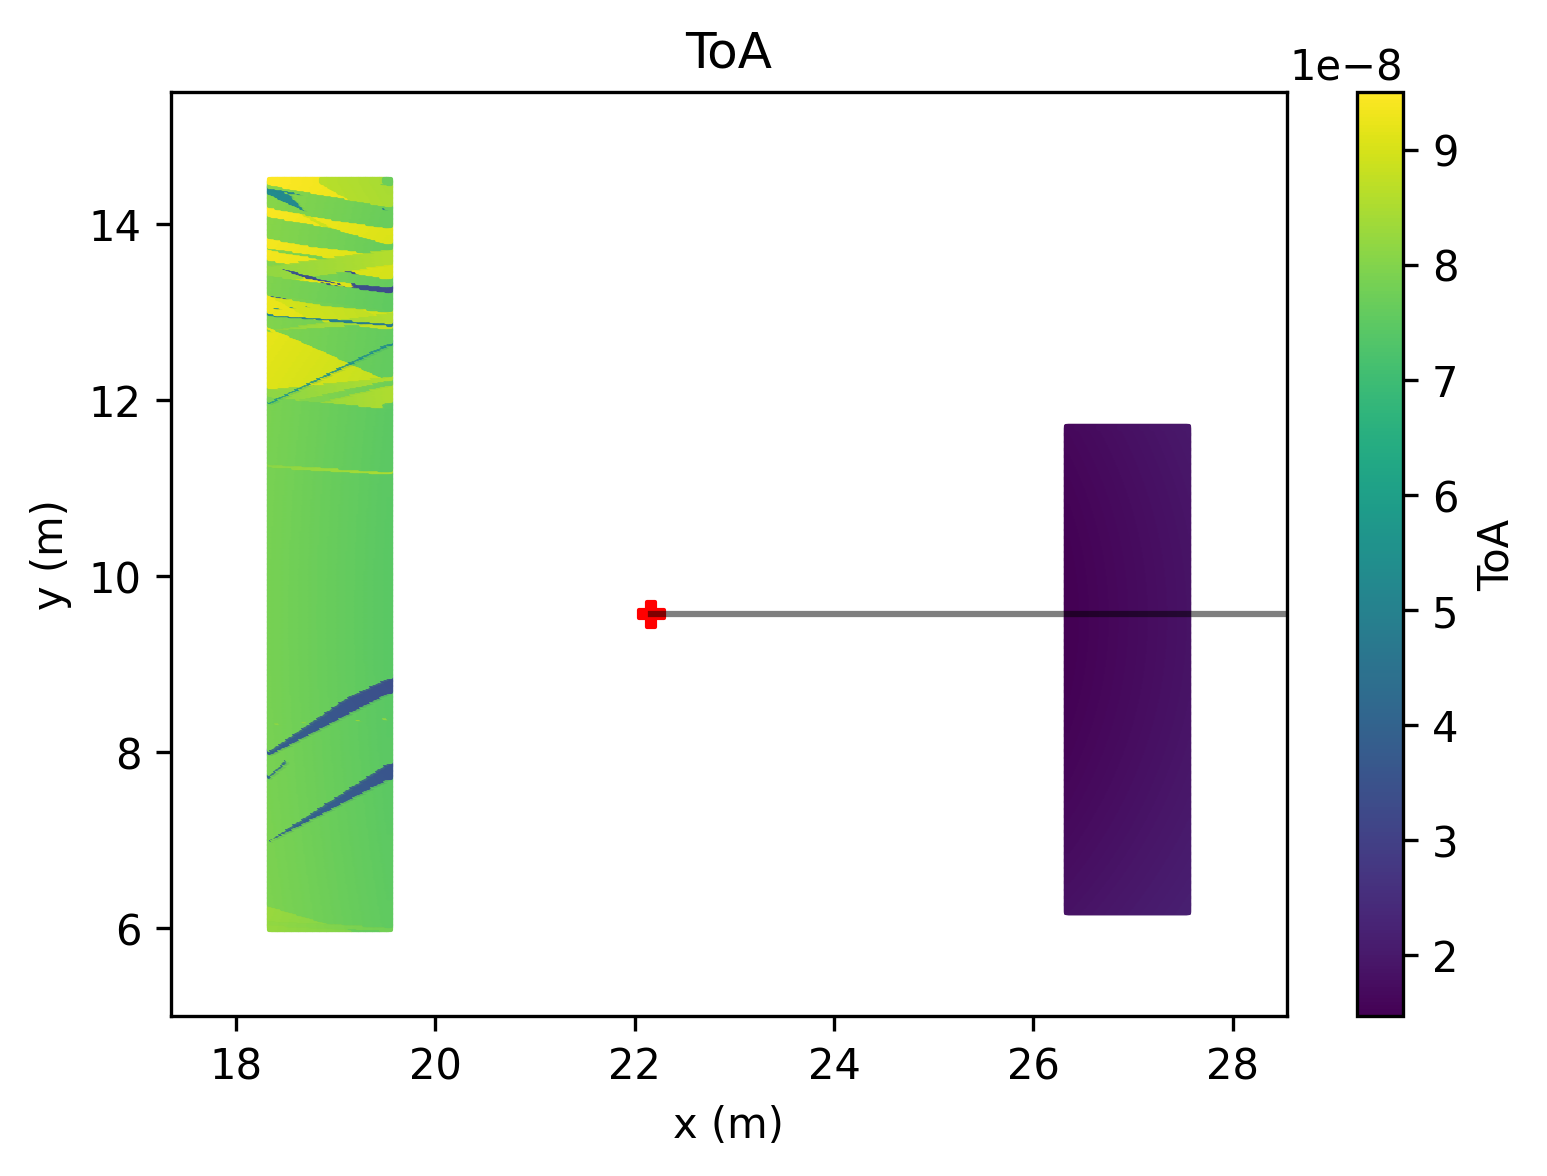

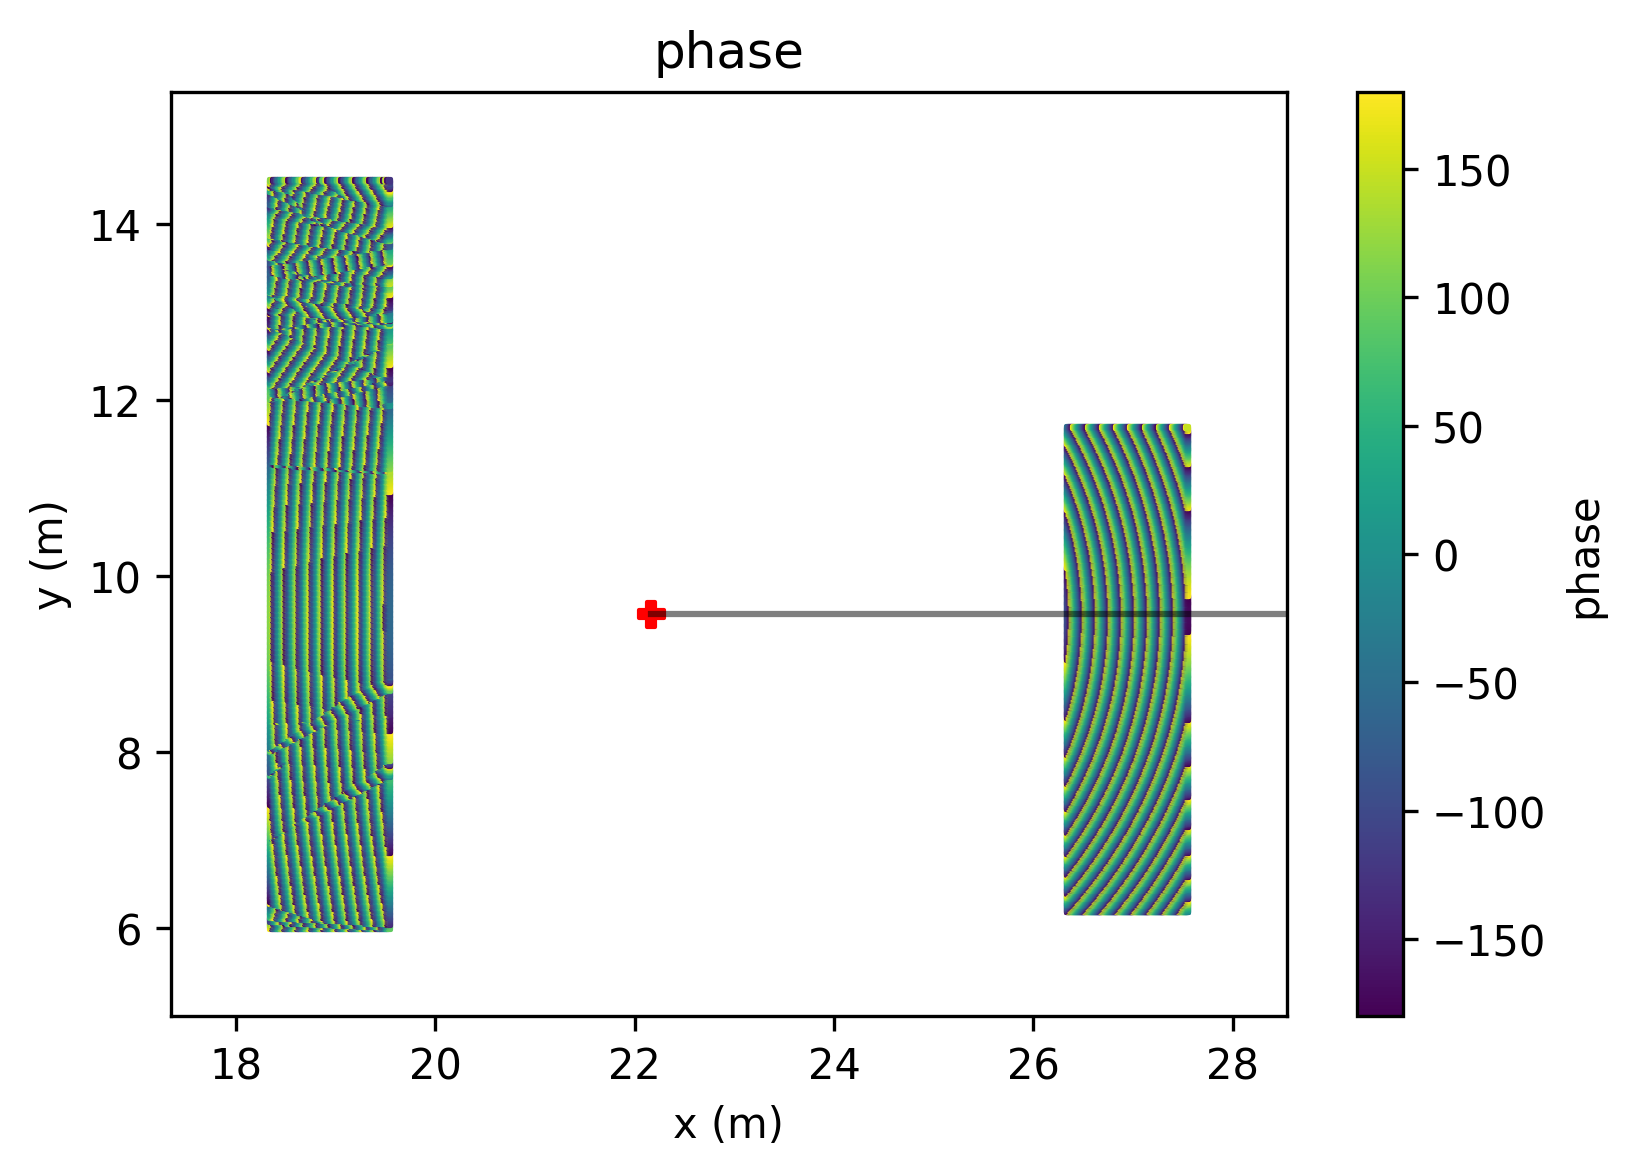

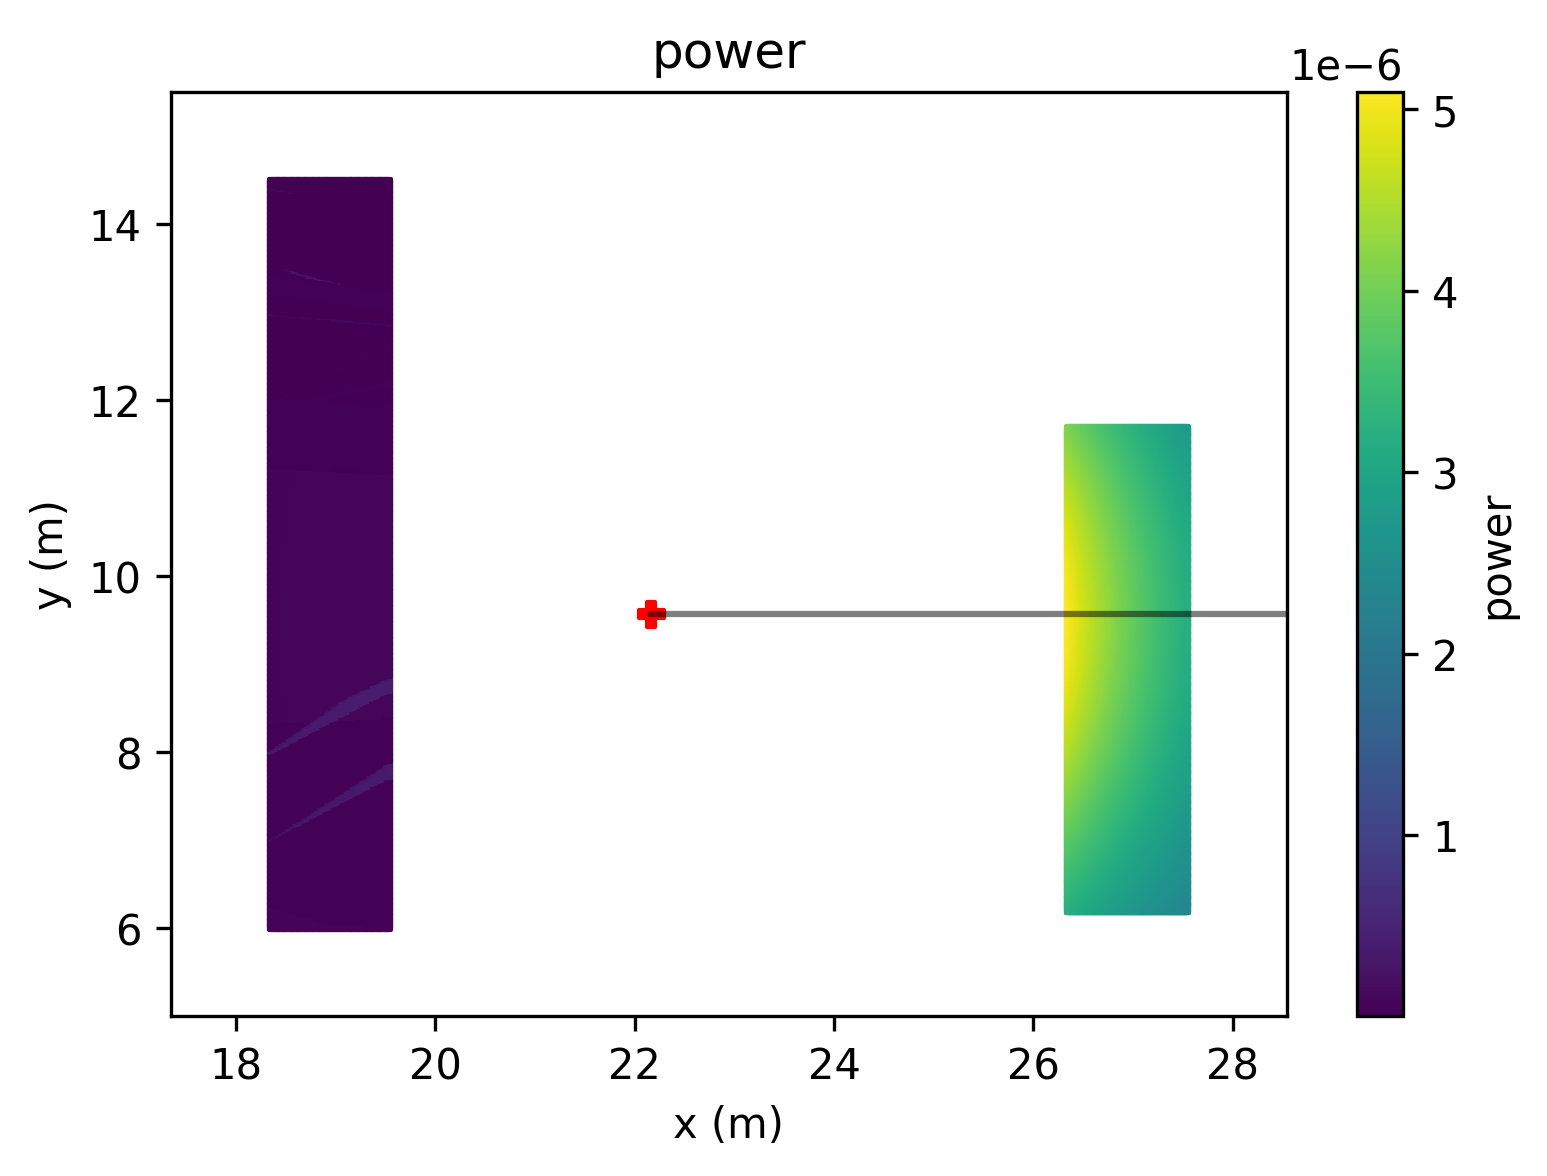

In [18]:
    
# Plot all path parameters
var_names = ['DoD_phi', 'DoD_theta', 'DoA_phi', 'DoA_theta', 'ToA', 'phase', 'power']
n_users = dataset[0]['user']['paths'].shape[0]
plt_map = np.zeros(n_users) * np.nan # set NaN to users with no paths
for var_name in var_names:
    plt_map = [dataset[0]['user']['paths'][i][var_name][0]
               if dataset[0]['user']['paths'][i]['num_paths'] else np.nan for i in range(n_users)]
    plot_coverage(dataset[0]['user']['location'], plt_map, bs_pos=dataset[0]['location'],
                  bs_ori=parameters['bs_antenna']['rotation']*np.pi/180,
                  proj_3D=False, title=var_name, cbar_title=var_name)

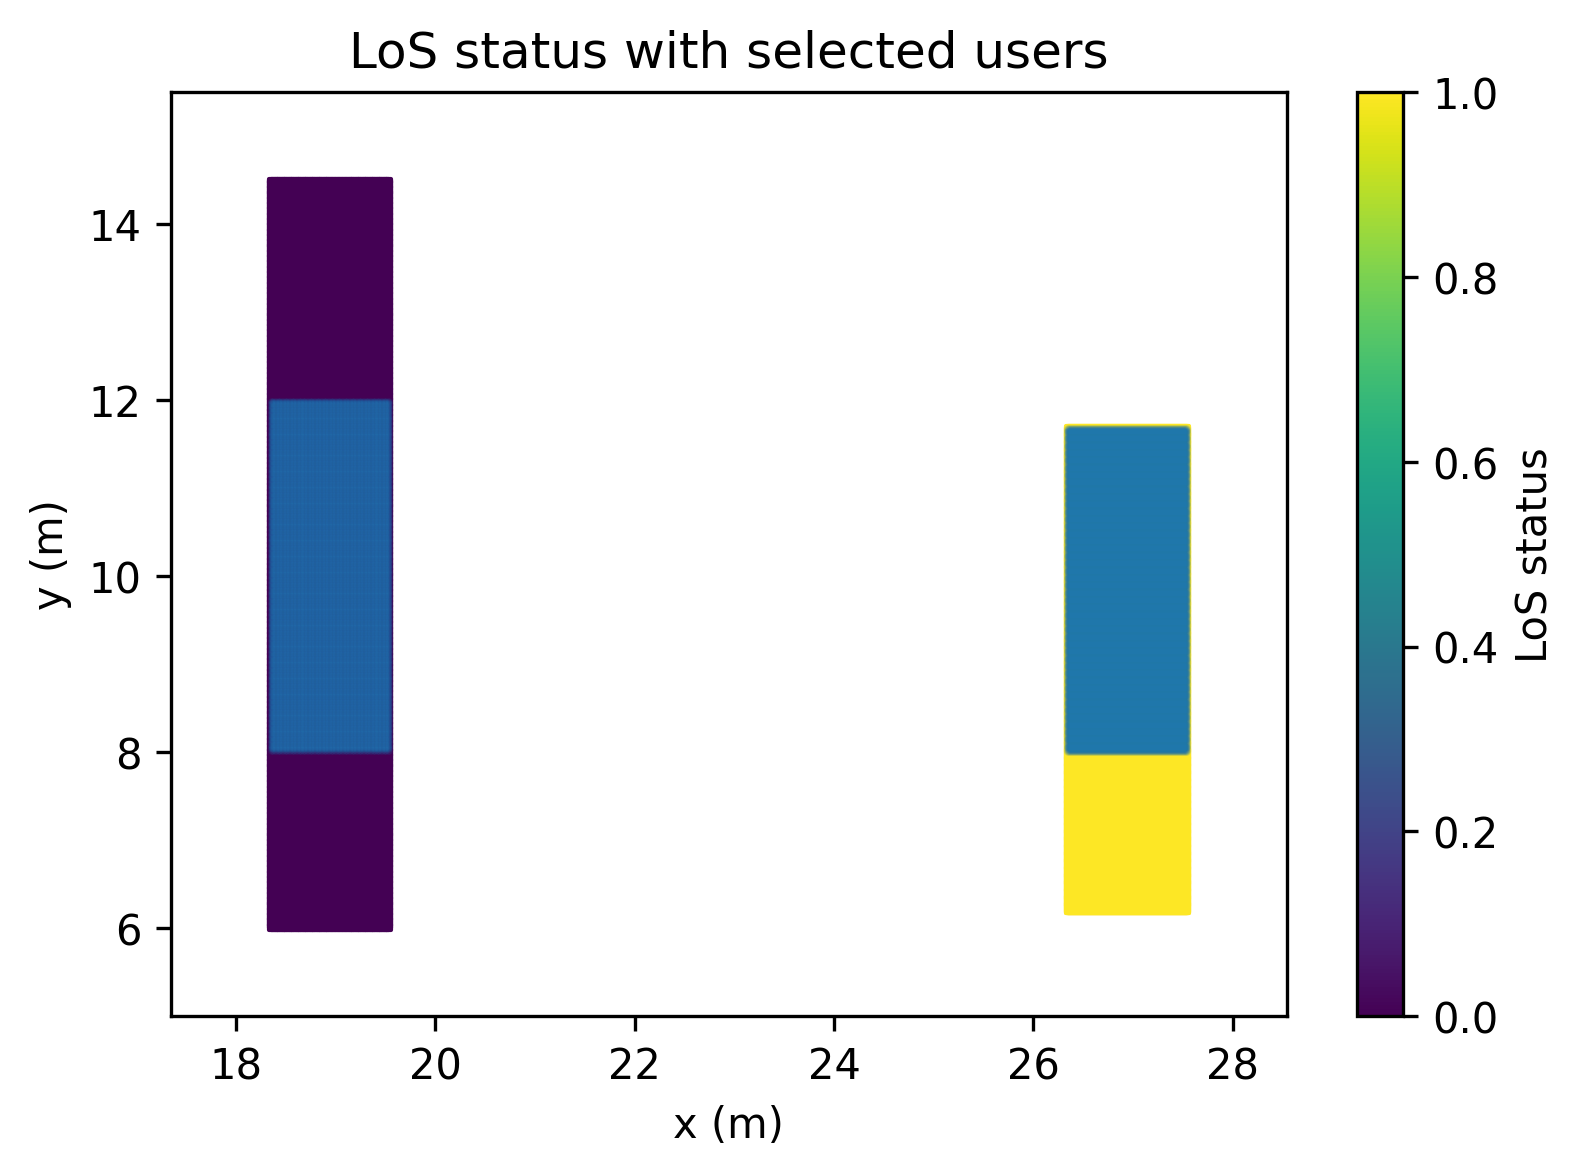

In [19]:
from DeepMIMOv3.utils import steering_vec, uniform_sampling, trim_by_idx, \
                             LinearPath, get_idxs_in_xy_box

# Make a codebook matrix with 25 beam steering vectors from -60º to 60º azimuth
n_beams = 25
beam_angles = np.around(np.linspace(-60, 60, n_beams), 2)
F1 = np.array([steering_vec(parameters['bs_antenna']['shape'], phi=azi,
                            spacing=parameters['bs_antenna']['spacing']).squeeze()
               for azi in beam_angles])
# F1 is n_beams x n_ant

# Select one every four indices across x and y directions. Result 16x less indices
uniform_idxs = uniform_sampling([4,4], n_rows=len(parameters['user_rows']), users_per_row=411)
# The values <n_rows> and  <users_per_row> should be acquired from the scenario page.

# Trim dataset without regenerating.
# dataset_t = trim_by_idx(dataset[0], uniform_idxs) # uniform_idxs obtained from uniform_sampling(.)

# obtain the indices of the users in the zone
idxs_in_box = get_idxs_in_xy_box(dataset[0]['user']['location'],
                                 x_min=18, x_max=28, y_min=8, y_max=12)

# show map
plot_coverage(dataset[0]['user']['location'], dataset[0]['user']['LoS'],
              title='LoS status with selected users', cbar_title='LoS status')

# show selected users in the map
plt.scatter(dataset[0]['user']['location'][idxs_in_box,0],
            dataset[0]['user']['location'][idxs_in_box,1],
            label='box A', s=2, lw=.1, alpha=.1)

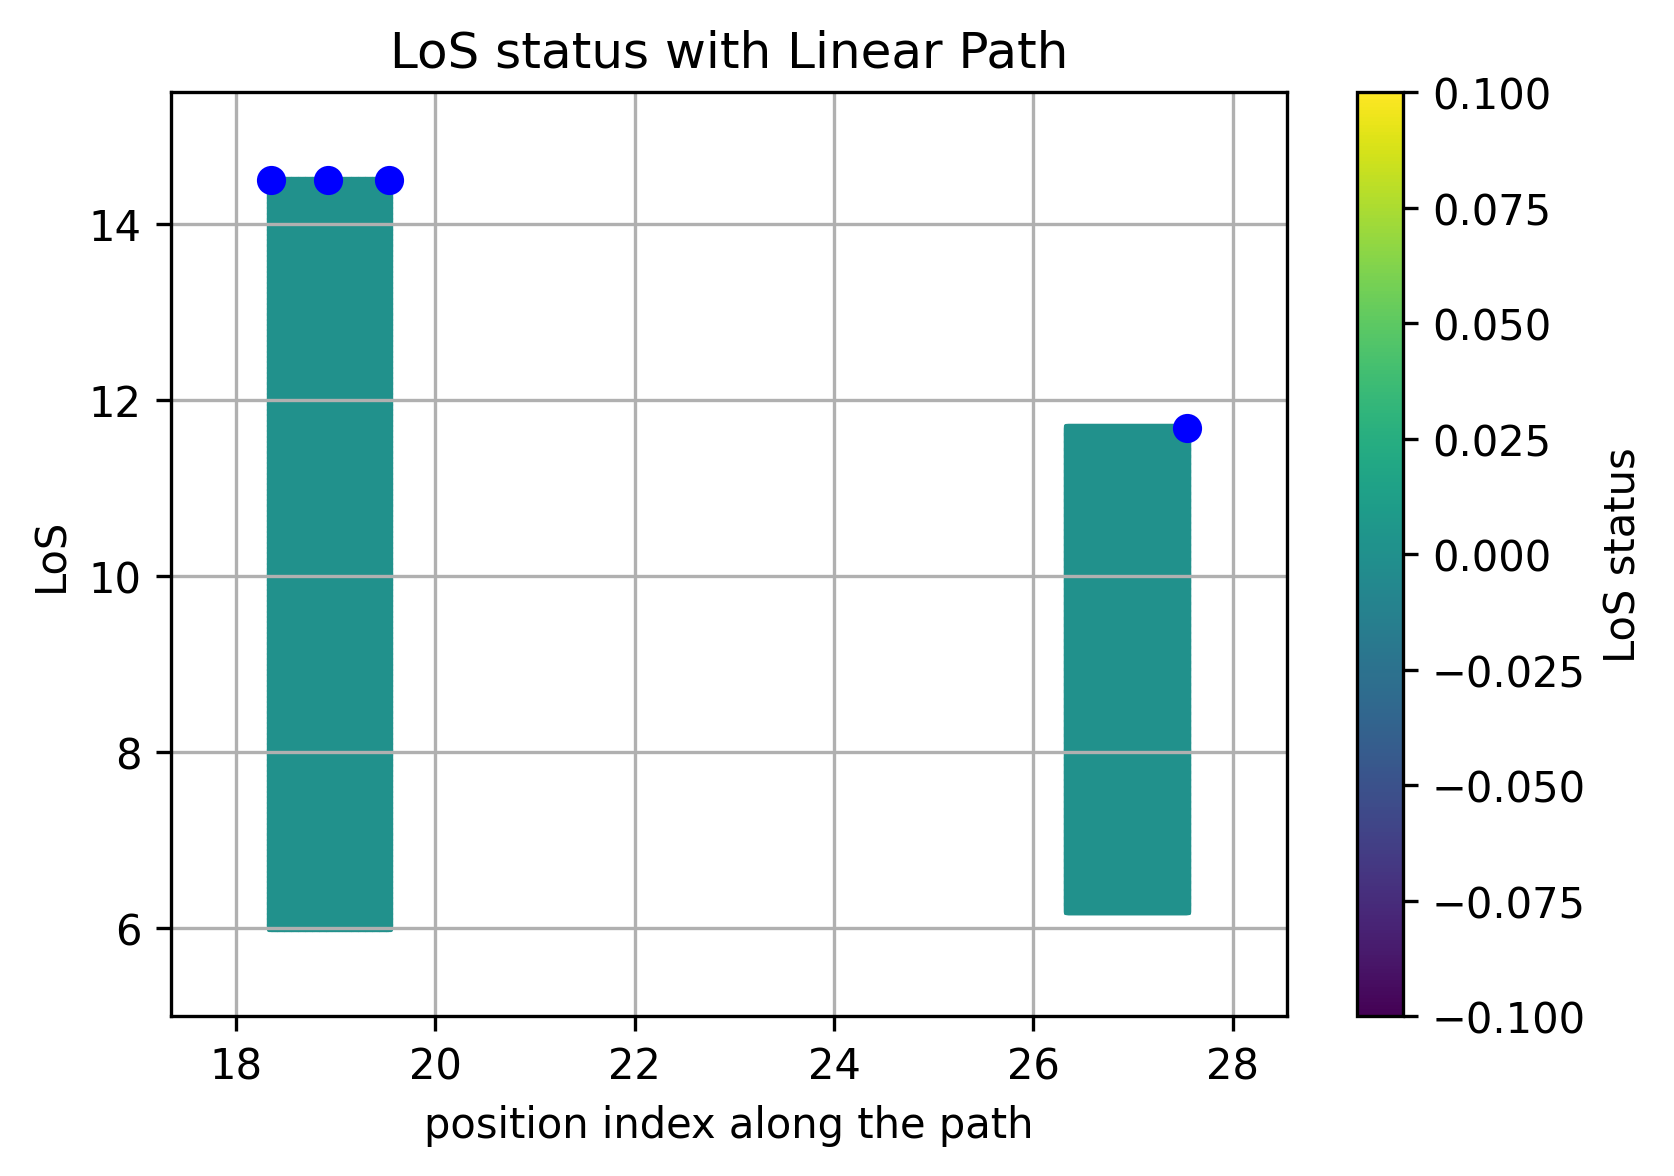

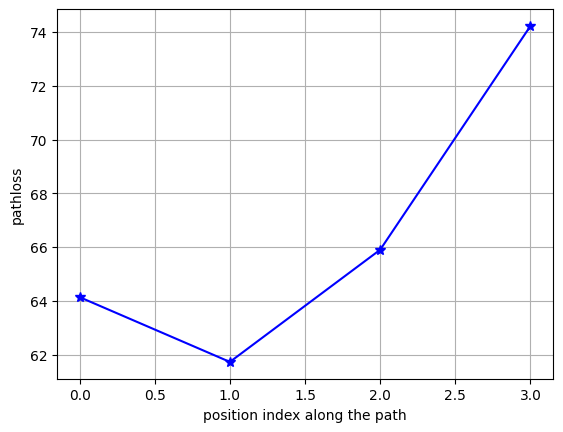

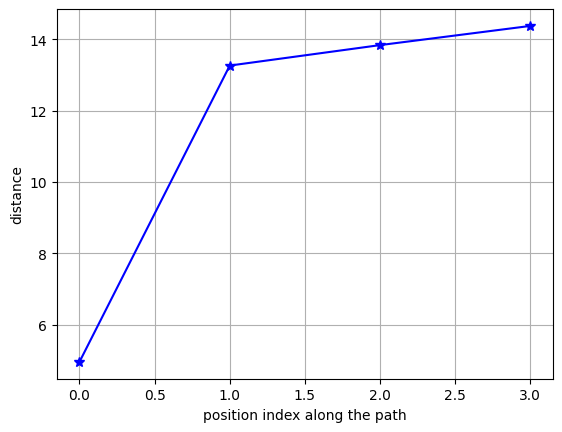

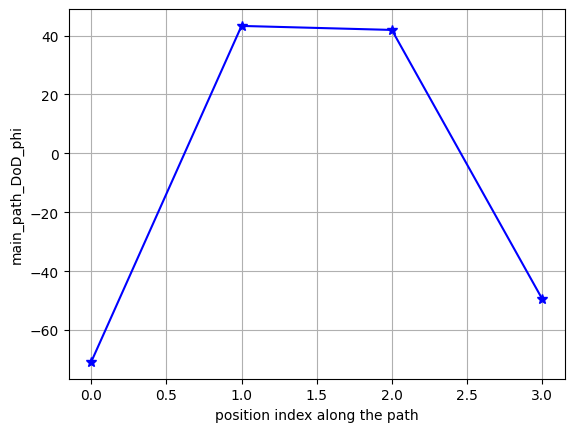

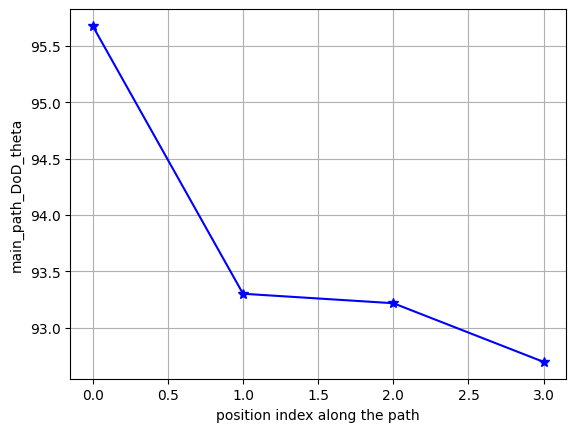

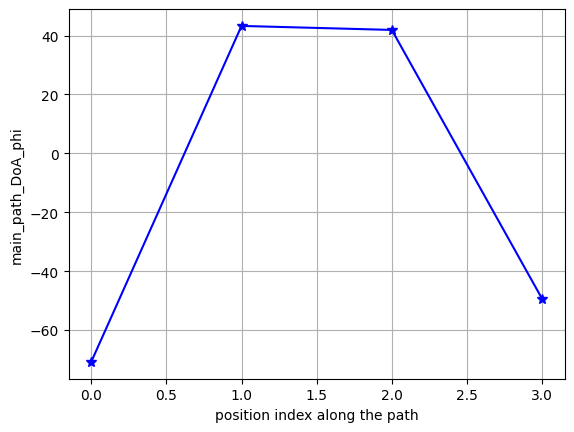

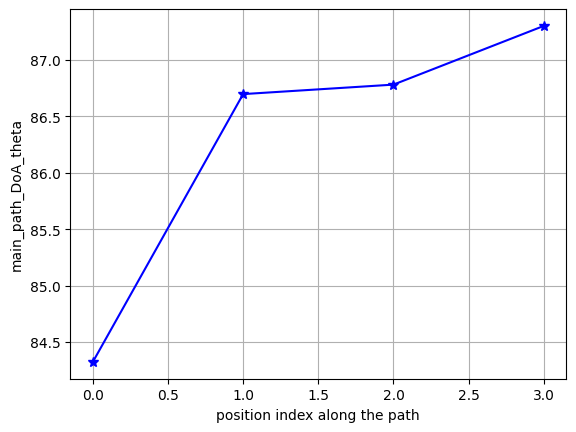

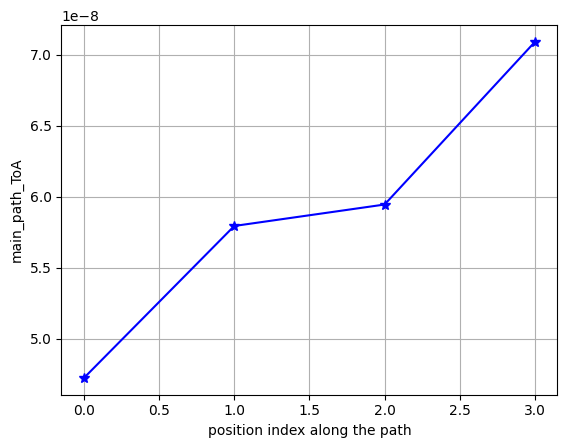

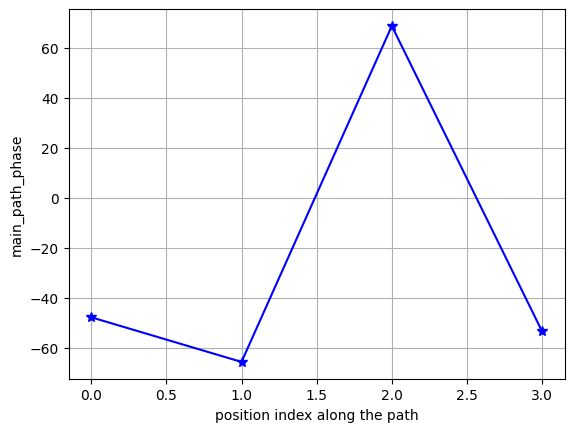

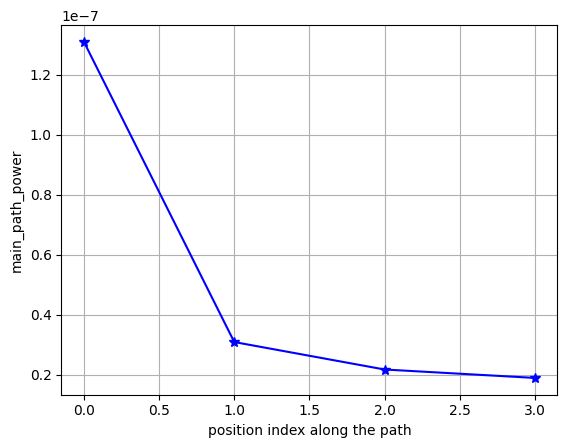

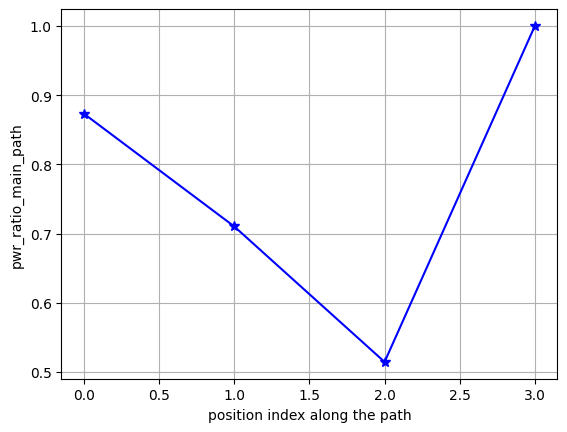

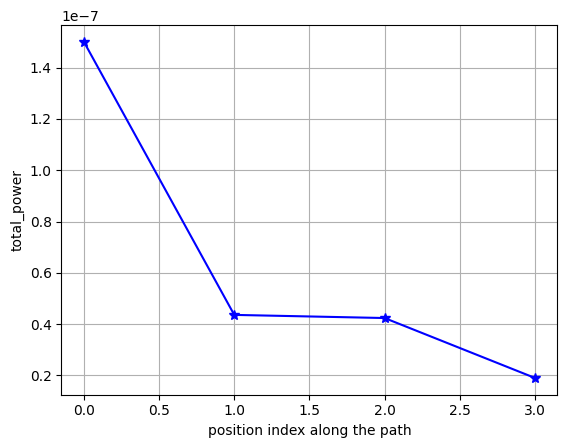

In [21]:
# Create a linear path
linpath = LinearPath(dataset[0], first_pos=[100, 90], last_pos=[-50, 90], n_steps=75)

# Show it on the map
plot_coverage(dataset[0]['user']['location'], dataset[0]['user']['LoS'],
              title='LoS status with Linear Path', cbar_title='LoS status')
plt.scatter(linpath.pos[:,0], linpath.pos[:,1], c='blue', label='linear path')

# Plot features along the path
for var_name in linpath.get_feature_names():
    plt.plot(getattr(linpath, var_name), ls='-',  c='blue', marker='*', markersize=7)
    plt.xlabel('position index along the path')
    plt.ylabel(f'{var_name}')
    plt.grid()
    plt.show()